In [1]:
import numpy as np
import matplotlib.pyplot as plt
from braid_analysis import flymath
from braid_analysis import braid_analysis_plots
import pynumdiff
import cvxpy
import figurefirst as fifi

In [2]:
import math

def create_ellipse_transform_matrix(a, b, theta_degrees):
    """
    Create a transformation matrix to convert a unit circle to a rotated ellipse.
    
    Parameters:
    a (float): Semi-major axis length
    b (float): Semi-minor axis length
    theta_degrees (float): Rotation angle in degrees (counterclockwise)
    
    Returns:
    numpy.ndarray: 2x2 transformation matrix
    """
    theta = math.radians(theta_degrees)
    cos_theta = math.cos(theta)
    sin_theta = math.sin(theta)
    
    matrix = np.array([
        [a * cos_theta, -b * sin_theta],
        [a * sin_theta,  b * cos_theta]
    ])

    return matrix

def value_to_eccentricity_exponential(value, decay=0.5):
    """
    Map value (0 to infinity) to eccentricity (0 to 1) using exponential.
    Fast initial rise, then gradual approach to 1.
    
    Parameters:
    value (float): Input value (0 to infinity)
    decay (float): Controls how quickly it approaches 1 (smaller = faster)
    
    Returns:
    float: Eccentricity (0 to 1)
    """
    return 1 - math.exp(-value / decay)

def eccentricity_to_axes(eccentricity, semi_major_axis=1.0):
    """
    Convert eccentricity to semi-major and semi-minor axis lengths.
    
    Parameters:
    eccentricity (float): Eccentricity (0 to 1)
    semi_major_axis (float): Length of semi-major axis
    
    Returns:
    tuple: (a, b) where a >= b
    """
    if eccentricity >= 1.0:
        eccentricity = 0.999  # Prevent b from becoming 0
    
    a = semi_major_axis
    b = a * math.sqrt(1 - eccentricity**2)
    return a, b

In [3]:
def get_course_and_trajec(wind_direction, wind_magnitude, beta=0, dt=None, t=None):
    if t is None:
        dt = 0.02
        t = np.arange(0, 10, dt)
    
    course_x = np.cos(t)
    course_y = np.sin(t)
    
    # speed = 1
    # xvel = speed*course_x
    # yvel = speed*course_y
    
    # x = np.cumsum(xvel)*dt
    # y = np.cumsum(yvel)*dt

    ecc = value_to_eccentricity_exponential(wind_magnitude, decay=0.05)
    a, b = eccentricity_to_axes(ecc)

    try:
        wd = wind_direction[0]
    except:
        wind_direction = [wind_direction,]


    if len(wind_direction) == 1:
        ellipse_matrix = create_ellipse_transform_matrix(a, b, wind_direction[0] +90)
        print(ellipse_matrix)
        
        course_xy = np.vstack((course_x, course_y))
        course_xy_ellipse = ellipse_matrix@course_xy
        
        course_x = course_xy_ellipse[0,:]
        course_y = course_xy_ellipse[1,:]
        
        course_angle = np.arctan2(course_y, course_x)
        beta = beta*ecc**6
        course_angle = course_angle*(1-beta) + math.radians(wind_direction[0])*beta

    else:
        course_angle_list = []
        for i, wd in enumerate(wind_direction):
            ellipse_matrix = create_ellipse_transform_matrix(a, b, wd +90)
        
            course_xy = np.vstack((course_x[i], course_y[i]))
            course_xy_ellipse = ellipse_matrix@course_xy
            
            course_x_el = course_xy_ellipse[0,0]
            course_y_el = course_xy_ellipse[1,0]
            
            course_angle = np.arctan2(course_y_el, course_x_el)
            beta = beta*ecc**6
            course_angle = course_angle*(1-beta) + math.radians(wd)*beta
            course_angle_list.append(course_angle)
        course_angle = np.array(course_angle_list)

    course_angle_cartesian_x = np.cos(course_angle)
    course_angle_cartesian_y = np.sin(course_angle)
    
    if 0:
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.plot(course_angle_cartesian_x, course_angle_cartesian_y, '.')
        ax.set_aspect('equal')



    gamma = 10
    
    course_cvx = cvxpy.Variable(len(course_angle))
    
    L1 = cvxpy.sum_squares(course_cvx - course_angle )
    L2 = cvxpy.sum_squares(cvxpy.diff(course_cvx))
    L3 = cvxpy.tv(cvxpy.diff(course_cvx))
    
    prob = cvxpy.Problem(cvxpy.Minimize(L1  + gamma*L2 + 1*L3))
    prob.solve(solver='MOSEK')
    
    #plt.plot(course_angle_unwrapped)
    #plt.plot(course_cvx.value)

    unwrapped_course_cvx = flymath.unwrap_angle(course_cvx.value, correction_window_for_2pi=20)
    
    smooth_course, _ = pynumdiff.total_variation_regularization.velocity(unwrapped_course_cvx, dt, [100])
    
    speed = 1
    velx = speed*np.cos(smooth_course)
    vely = speed*np.sin(smooth_course)
    
    x = np.cumsum(velx)*dt
    y = np.cumsum(vely)*dt

    return smooth_course, x, y, course_x, course_y

# This is the meat

adjusting wind_magnitude will smoothly change from casting and circling

adjusting whether the wind direction is random or constant will smoothly change from randomly searching to casting

to see casting:
*  choose highish wind magnitude (0.5)
*  choose constant wind direction

to see circling:
* choose low wind magnitude
* (wind direction is mostly irrelevant)

to see random search:
* choose intermediate wind magnitude (0.1)
* choose random wind direction

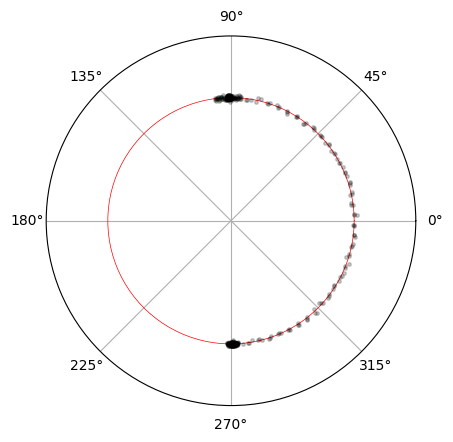

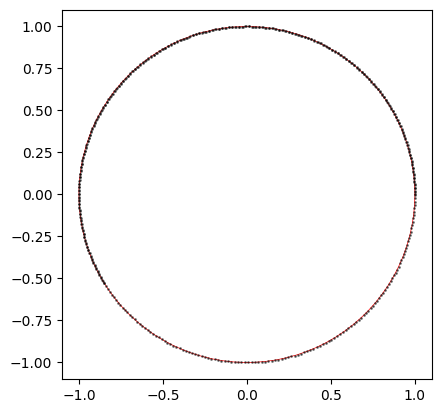

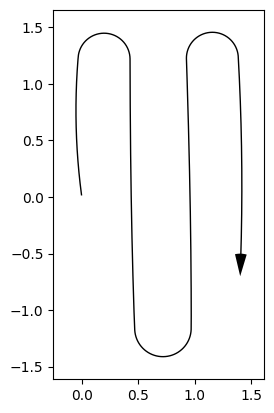

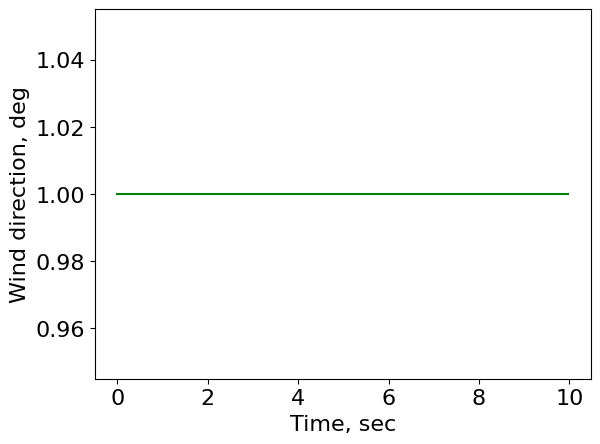

In [30]:
dt = 0.02
t = np.arange(0, 10, dt)

random_wind_direction = np.cumsum(np.random.normal(0,2,len(t)))
constant_wind_direction = np.ones_like(random_wind_direction)


# MAKE SELECTIONS HERE ###########################################
wind_direction = constant_wind_direction
wind_magnitude = 0.5
##################################################################

smooth_course, x, y, course_x, course_y = get_course_and_trajec(wind_direction, wind_magnitude, beta=0, dt=dt, t=t)

course_angle_cartesian_x = np.cos(smooth_course)
course_angle_cartesian_y = np.sin(smooth_course)

fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')

center = [0,0]
radius=1
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(theta, np.ones_like(theta), color='red', linewidth=0.5)

ax.plot(smooth_course, 
        np.ones_like(smooth_course)  + np.random.normal(0,0.01, len(smooth_course)), 
        '.', markersize=5, color='black', alpha=0.2)

ax.set_rticks([])
ax.set_rlim(0,1.5)

#################
fig = plt.figure()
ax = fig.add_subplot(111)

center = [0,0]
radius=1
theta = np.linspace(0, 2*np.pi, 100)
xc = center[0] + radius * np.cos(theta)
yc = center[1] + radius * np.sin(theta)
ax.plot(xc, yc, color='red', linewidth=0.5)

ax.plot(course_x, course_y, 
        '.', markersize=2, color='black', alpha=0.5)
ax.set_aspect('equal')
ax.set_xlim(-1.1,1.1)
ax.set_ylim(-1.1,1.1)


#################
fig = plt.figure()
ax = fig.add_subplot(111)
braid_analysis_plots.plot_arrowhead_trajectory(x,y,arrow_length=0.2, ax=ax)
ax.set_aspect('equal')
ax.set_xlim(np.min(x)-0.2,np.max(x)+0.2)
ax.set_ylim(np.min(y)-0.2,np.max(y)+0.2)


##################
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, wind_direction, color='green')
ax.set_xlabel('Time, sec')
ax.set_ylabel('Wind direction, deg')
fifi.mpl_functions.set_fontsize(ax, 16)